In [1]:
import pandas as pd

# 1. Fusion des 2 fichiers 2024 et 2024

In [13]:
import os
os.chdir("C:/Users/carine/mars26_bds_immo")
print(os.getcwd())

C:\Users\carine\mars26_bds_immo


In [14]:
file_2024 = "data/raw/ValeursFoncieres-2024.txt"
file_2025 = "data/raw/ValeursFoncieres-2025.txt"

output_file = "data/raw/ValeursFoncieres-merged.txt"

In [15]:
import os
os.makedirs("data/raw", exist_ok=True)

In [16]:
with open(output_file, "w", encoding="utf-8") as out:

    for file in [file_2024, file_2025]:
        print(f"Traitement : {file}")

        with open(file, "r", encoding="utf-8") as f:
            for line in f:
                out.write(line)

Traitement : data/raw/ValeursFoncieres-2024.txt
Traitement : data/raw/ValeursFoncieres-2025.txt


In [17]:
print("Fusion terminée ✔️ fichier créé :", output_file)

Fusion terminée ✔️ fichier créé : data/raw/ValeursFoncieres-merged.txt


In [26]:
# 1. Chargement des données
# 2. Audit des colonnes
# 3. Nettoyage colonne par colonne
# 4. Feature engineering (si besoin)
# 5. Normalisation / encodage
# 6. Dataset final

# 2. Chargement des données

In [37]:
import pandas as pd

df = pd.read_csv(
    "data/raw/ValeursFoncieres-merged.txt",
    sep="|",
    low_memory=False
)

# 3. Audit des colonnes

## 3.1 Aperçu du DF

In [38]:
df.head()

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,02/01/2024,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,P,NaN,99
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000002,03/01/2024,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,S,NaN,115
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,08/01/2024,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,S,NaN,497
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,03/01/2024,Vente,...,NaN,2,3,Dépendance,NaN,0,0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,03/01/2024,Vente,...,NaN,1,3,Dépendance,NaN,0,0,NaN,NaN,NaN


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7214761 entries, 0 to 7214760
Data columns (total 43 columns):
 #   Column                      Dtype
---  ------                      -----
 0   Identifiant de document     str  
 1   Reference document          str  
 2   1 Articles CGI              str  
 3   2 Articles CGI              str  
 4   3 Articles CGI              str  
 5   4 Articles CGI              str  
 6   5 Articles CGI              str  
 7   No disposition              str  
 8   Date mutation               str  
 9   Nature mutation             str  
 10  Valeur fonciere             str  
 11  No voie                     str  
 12  B/T/Q                       str  
 13  Type de voie                str  
 14  Code voie                   str  
 15  Voie                        str  
 16  Code postal                 str  
 17  Commune                     str  
 18  Code departement            str  
 19  Code commune                str  
 20  Prefixe de section          str  
 

In [40]:
df.shape

(7214761, 43)

In [41]:
df.columns

Index(['Identifiant de document', 'Reference document', '1 Articles CGI',
       '2 Articles CGI', '3 Articles CGI', '4 Articles CGI', '5 Articles CGI',
       'No disposition', 'Date mutation', 'Nature mutation', 'Valeur fonciere',
       'No voie', 'B/T/Q', 'Type de voie', 'Code voie', 'Voie', 'Code postal',
       'Commune', 'Code departement', 'Code commune', 'Prefixe de section',
       'Section', 'No plan', 'No Volume', '1er lot',
       'Surface Carrez du 1er lot', '2eme lot', 'Surface Carrez du 2eme lot',
       '3eme lot', 'Surface Carrez du 3eme lot', '4eme lot',
       'Surface Carrez du 4eme lot', '5eme lot', 'Surface Carrez du 5eme lot',
       'Nombre de lots', 'Code type local', 'Type local', 'Identifiant local',
       'Surface reelle bati', 'Nombre pieces principales', 'Nature culture',
       'Nature culture speciale', 'Surface terrain'],
      dtype='str')

In [42]:
(df.isna().mean() * 100).sort_values(ascending=False)

Identifiant de document       99.999986
Reference document            99.999986
1 Articles CGI                99.999986
2 Articles CGI                99.999986
3 Articles CGI                99.999986
4 Articles CGI                99.999986
5 Articles CGI                99.999986
Identifiant local             99.999986
Surface Carrez du 5eme lot    99.970408
Surface Carrez du 4eme lot    99.917572
No Volume                     99.764802
5eme lot                      99.747878
Surface Carrez du 3eme lot    99.672837
4eme lot                      99.455630
3eme lot                      98.344505
Surface Carrez du 2eme lot    97.043021
Nature culture speciale       95.524536
B/T/Q                         95.516719
Prefixe de section            95.139312
Surface Carrez du 1er lot     90.864992
2eme lot                      90.586729
1er lot                       69.242197
Nombre pieces principales     40.840521
Surface reelle bati           40.840521
Code type local               40.778121


## Analyse des valeurs manquantes

Certaines colonnes présentent plus de 90% de valeurs manquantes.
Ces colonnes concernent principalement des informations spécifiques
(lots multiples, surfaces Carrez, identifiants techniques).

Ces variables ne sont pas pertinentes pour l'analyse principale
et seront supprimées lors du preprocessing.

In [43]:
df.dtypes

Identifiant de document       str
Reference document            str
1 Articles CGI                str
2 Articles CGI                str
3 Articles CGI                str
4 Articles CGI                str
5 Articles CGI                str
No disposition                str
Date mutation                 str
Nature mutation               str
Valeur fonciere               str
No voie                       str
B/T/Q                         str
Type de voie                  str
Code voie                     str
Voie                          str
Code postal                   str
Commune                       str
Code departement              str
Code commune                  str
Prefixe de section            str
Section                       str
No plan                       str
No Volume                     str
1er lot                       str
Surface Carrez du 1er lot     str
2eme lot                      str
Surface Carrez du 2eme lot    str
3eme lot                      str
Surface Carrez

✔ tout en string = normal au départ
✔ pas une erreur de merge
✔ problème de typage uniquement
✔ étape suivante = preprocessing

Correction des types des colonnes principales

In [44]:
df["Valeur fonciere"] = (
    df["Valeur fonciere"]
    .str.replace(",", ".")
)

df["Valeur fonciere"] = pd.to_numeric(df["Valeur fonciere"], errors="coerce")

In [45]:
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

In [46]:
df["Surface reelle bati"] = pd.to_numeric(df["Surface reelle bati"], errors="coerce")
df["Surface terrain"] = pd.to_numeric(df["Surface terrain"], errors="coerce")

In [48]:
cols_lots = [
    "Nombre de lots",
    "1er lot",
    "2eme lot",
    "3eme lot",
    "4eme lot",
    "5eme lot"
]

for col in cols_lots:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [49]:
df["Nombre pieces principales"] = pd.to_numeric(
    df["Nombre pieces principales"],
    errors="coerce"
)

In [53]:
df.dtypes

Identifiant de document                 str
Reference document                      str
1 Articles CGI                          str
2 Articles CGI                          str
3 Articles CGI                          str
4 Articles CGI                          str
5 Articles CGI                          str
No disposition                          str
Date mutation                datetime64[us]
Nature mutation                         str
Valeur fonciere                     float64
No voie                                 str
B/T/Q                                   str
Type de voie                            str
Code voie                               str
Voie                                    str
Code postal                             str
Commune                                 str
Code departement                        str
Code commune                            str
Prefixe de section                      str
Section                                 str
No plan                         

Colonnes OK en STR (ne pas toucher)

👉 Identifiants / codes / texte pur

Identifiant de document
Reference document
No disposition
Code voie
Voie
Commune
Code postal
Code departement
Code commune
Section
No plan
Nature mutation
Type de voie

👉 ✔ on les garde en str (ou category plus tard)

B. Colonnes à convertir en numériques (IMPORTANT)
🔹 lots
1er lot, 2eme lot, 3eme lot...
Nombre de lots

👉 souvent :

soit numériques
soit NaN

Colonnes à garder mais potentiellement encoder
Type local
Nature culture
Nature culture speciale
B/T/Q

👉 ces colonnes sont :

catégorielles
utiles pour analyse

✔ pas de conversion numérique

Colonnes probablement inutiles (option nettoyage)

Très fortes valeurs manquantes :

Articles CGI
Surface Carrez (très incomplet)
Identifiant local

👉 souvent supprimées en analyse classique

Encore à corriger
Surface Carrez : encore en string ❗

✔ problème :

virgules possibles
valeurs manquantes énormes

👉 soit :

conversion float
soit suppression (souvent choisi)

Colonnes catégorielles (très importantes)
Type local
Nature culture
Commune
Code postal

👉 ✔ parfait en str
👉 mais tu pourras les encoder plus tard

## Identifiants techniques
Ces colonnes ne sont pas utiles pour l’analyse.

In [54]:
cols_drop = [
    "Identifiant de document",
    "Reference document",
    "Identifiant local"
]

df = df.drop(columns=cols_drop)

## Articles CGI
Colonnes administratives non utilisées en analyse.

In [55]:
cgi_cols = [
    "1 Articles CGI",
    "2 Articles CGI",
    "3 Articles CGI",
    "4 Articles CGI",
    "5 Articles CGI"
]

df = df.drop(columns=cgi_cols)

## No disposition
Identifiant de transaction interne.

In [56]:
df = df.drop(columns=["No disposition"])

## Date mutation
Date de vente du bien immobilier. Transformation en datetime

In [57]:
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

## Nature mutation
Type de transaction (vente, succession, etc.)

Cette colonne décrit le contexte juridique de la transaction immobilière.

Elle permet de distinguer :
- les ventes classiques
- les ventes sur plan (VEFA)
- les ventes judiciaires ou forcées

Cette variable est conservée comme variable catégorielle pour l’analyse.

In [58]:
df["Nature mutation"] = df["Nature mutation"].astype("category")

In [59]:
df["Nature mutation"].value_counts()

Nature mutation
Vente                                 6773005
Vente en l'état futur d'achèvement     314254
Echange                                 92974
Vente terrain à bâtir                   15616
Adjudication                            14658
Expropriation                            4253
Nature mutation                             1
Name: count, dtype: int64

In [60]:
df["Nature mutation"].value_counts(normalize=True) * 100

Nature mutation
Vente                                 93.877053
Vente en l'état futur d'achèvement     4.355709
Echange                                1.288664
Vente terrain à bâtir                  0.216445
Adjudication                           0.203167
Expropriation                          0.058949
Nature mutation                        0.000014
Name: proportion, dtype: float64

<Axes: xlabel='Nature mutation'>

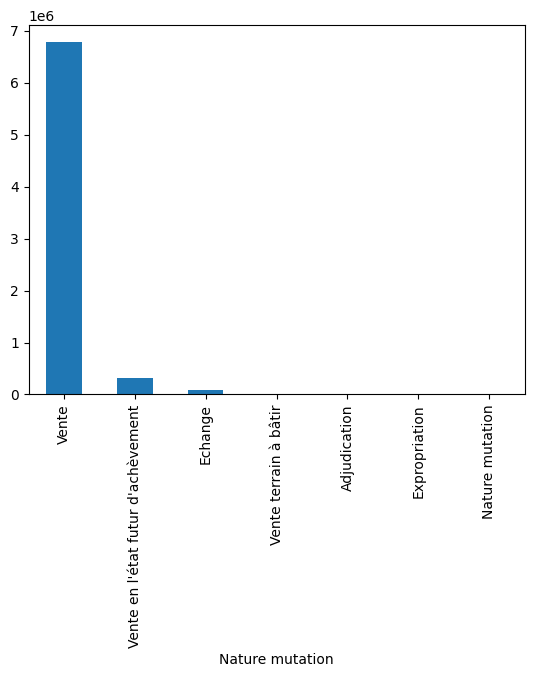

In [61]:
df["Nature mutation"].value_counts().plot(kind="bar")

## Adresse
Informations de localisation du bien.
## Analyse des colonnes d’adresse

Les colonnes liées à l’adresse présentent des niveaux de complétude variables :

- Voie : quasi complète (0.6% de valeurs manquantes)
- No voie : partiellement renseigné (36%)
- Type de voie : partiellement renseigné (38%)
- B/T/Q : très peu renseigné (95%)

Conclusion :
La colonne "Voie" est conservée car elle est la plus fiable.
Les autres colonnes sont supprimées pour éviter le bruit dans l’analyse.

In [62]:
df[["No voie", "Type de voie", "Voie", "B/T/Q"]].head(10)

,No voie,Type de voie,Voie,B/T/Q
0,NaN,NaN,LE DELIVRE,NaN
1,NaN,NaN,CHEVRY DESSOUS,NaN
2,NaN,NaN,PIN HAMEAU,NaN
3,29,PL,DU JURA,NaN
4,9001,PL,DU JURA,NaN
5,29,PL,DU JURA,NaN
6,29,PL,DU JURA,NaN
7,NaN,NaN,AU CHAUME,NaN
8,NaN,NaN,LES FATES,NaN
9,NaN,NaN,LES FATES,NaN


In [63]:
df[["No voie", "Type de voie", "Voie", "B/T/Q"]].isna().mean() * 100

No voie         36.750601
Type de voie    38.762739
Voie             0.597580
B/T/Q           95.516719
dtype: float64

In [64]:
df = df.drop(columns=["No voie", "Type de voie", "B/T/Q"])

## Code postal ET Commune
 Localisation géographique
 Analyse des variables géographiques

Les variables "Code postal" et "Commune" permettent d’identifier la localisation des biens.

Observations :
- un grand nombre de communes différentes est présent
- certaines communes concentrent une grande partie des transactions
- un code postal peut correspondre à plusieurs communes

Ces variables sont essentielles pour l’analyse des prix immobiliers.

In [65]:
df["Code postal"] = df["Code postal"].astype(str).str.zfill(5)
df["Commune"] = df["Commune"].astype("category")
df["Code departement"] = df["Code departement"].astype(str)

In [66]:
df["Code postal"].nunique()

5868

In [67]:
df["Commune"].nunique()

31325

In [68]:
df["Commune"].value_counts().head(10)

Commune
TOULOUSE         47159
NICE             41605
MONTPELLIER      27334
BORDEAUX         27136
NANTES           27102
SAINT-ETIENNE    19687
RENNES           19678
LILLE            18839
DIJON            18009
TOULON           17755
Name: count, dtype: int64

In [69]:
df["Code postal"].value_counts().head(10)

Code postal
21000    17903
75015    17133
75016    15533
06000    14696
29200    14119
89000    13658
51100    13645
75018    13439
54000    13224
75017    12997
Name: count, dtype: int64

In [70]:
df[["Code postal", "Commune"]].isna().mean() * 100

Code postal    0.603637
Commune        0.000000
dtype: float64

In [ ]:
# nombre de communes pour un même code postal
df.groupby("Code postal")["Commune"].nunique().sort_values(ascending=False).head(10)

Code postal
51300    46
51800    44
70000    42
88500    42
80140    39
10500    36
70100    36
70500    36
39570    36
65100    36
Name: Commune, dtype: int64